# Контрольная классификация GSR-Net: Cats vs Dogs (grayscale, 256×256) — V04

## Цель

Верификация обучаемости архитектуры GSR-Net на задаче семантической классификации
(серия 1 ВКР) перед применением к стеганоанализу (серии 2–3).


## Конфигурация эксперимента

| Параметр | Значение |
|---|---|
| **Архитектура** | GSR-Net (ResBlock+SE, reduction=4, блоков [2,2,2,2]) |
| **Входные данные** | Grayscale, 256×256, 1 канал |
| **Датасет** | Cats-vs-Dogs-Gray: Cat≈1000, Dog≈1000 |
| **Разбиение** | Holdout: Train 70% / Val 15% / Test 15% |
| **Batch size** | 32 |
| **Learning rate** | 1e-3 → 1e-5 (CosineAnnealingLR) |
| **Эпох** | 35 |
| **HPF** | Обучаемый (Kaiming init) + BN + ReLU |
| **Оптимизатор** | Adam, weight_decay=1e-4 |
| **Loss** | CrossEntropyLoss |
| **Dropout** | Dropout2d(0.1) + Dropout(0.3) |
| **Grad clipping** | max_norm=1.0 |

In [ ]:
# Монтирование Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Импорт библиотек

import os
import json
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [ ]:
# 2. Глобальные настройки

# Фиксация seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Константы
IMAGE_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 35
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Пути
DATASET_PATH = "/content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000"
SAVE_DIR = "/content/drive/MyDrive/FQW/сat-dog_gsrnet_256_V04"
os.makedirs(SAVE_DIR, exist_ok=True)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Память: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Устройство: cuda
GPU: NVIDIA A100-SXM4-40GB
Память: 42.41 GB


In [ ]:
# 3. Загрузка и анализ датасета

dataset_root = Path(DATASET_PATH)
print(f"Сканирование: {dataset_root}")

data = []
for label_name, label_num in [("cat", 0), ("dog", 1)]:
    folder = dataset_root / label_name
    if folder.exists():
        for img_path in sorted(folder.glob("*.*")):
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                data.append({
                    "path": str(img_path),
                    "label": label_name,
                    "label_num": label_num,
                    "filename": img_path.name,
                })
        count = len([d for d in data if d["label"] == label_name])
        print(f"  {label_name}: {count}")
    else:
        print(f"  Папка не найдена: {folder}")

df = pd.DataFrame(data)
print(f"\nВсего изображений: {len(df)}")
print(f"Баланс классов:")
print(df["label"].value_counts())

# Разделение: 70 / 15 / 15
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED
)

print(f"\nРазделение:")
print(f"  Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

Сканирование: /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000
  cat: 999
  dog: 1000

Всего изображений: 1999
Баланс классов:
label
dog    1000
cat     999
Name: count, dtype: int64

Разделение:
  Train: 1399 (70.0%)
  Val:   300 (15.0%)
  Test:  300 (15.0%)


In [ ]:
# 4. АРХИТЕКТУРА GSR-Net
#
# Увеличена ёмкость [2,2,2,2] блоков (~9.2M), снижен Dropout.
# HPF → BN → ReLU (семантическая задача, без Tanh+Abs).


class SEBlock(nn.Module):
    """Squeeze-and-Excitation: GAP → FC(C→C//r) → ReLU → FC(C//r→C) → Sigmoid → Scale."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class ResidualBlock(nn.Module):
    """Conv → BN → ReLU → Conv → BN → SE → + shortcut → ReLU."""
    def __init__(self, in_ch, out_ch, stride=1, reduction=4):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.se = SEBlock(out_ch, reduction=reduction)
        self.relu = nn.ReLU(inplace=True)

        if in_ch != out_ch or stride != 1:
            sc = []
            if stride > 1:
                sc.append(nn.AvgPool2d(stride, stride, ceil_mode=True))
            sc += [nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch)]
            self.shortcut = nn.Sequential(*sc)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        return self.relu(self.se(self.block(x)) + self.shortcut(x))


class GSRNet_V04(nn.Module):
    """
    GSR-Net для контрольной классификации (Cats vs Dogs).

    Вход: [B, 1, 256, 256] → Выход: [B, 2] (логиты для CrossEntropyLoss)

    Архитектура:
    - Обучаемый HPF (Conv2d 5×5, 1→64) + BN + ReLU
    - 8 ResBlock+SE: [2,2,2,2] блоков, каналы 64→128→256→512
    - Dropout2d(0.1) между группами
    - GAP → Dropout(0.3) → FC(512, 2)
    """
    def __init__(self, num_classes=2, reduction=4):
        super().__init__()

        # HPF: обучаемый + ReLU (семантическая задача)
        self.hpf = nn.Conv2d(1, 64, kernel_size=5, padding=2, bias=False)
        self.hpf_bn = nn.BatchNorm2d(64)
        self.hpf_relu = nn.ReLU(inplace=True)

        # 4 группы по 2 блока = 8 блоков
        self.layer1 = self._make_layer(64,  64,  n_blocks=2, stride=1, reduction=reduction)  # 256×256
        self.drop1  = nn.Dropout2d(0.1)
        self.layer2 = self._make_layer(64,  128, n_blocks=2, stride=2, reduction=reduction)  # 128×128
        self.drop2  = nn.Dropout2d(0.1)
        self.layer3 = self._make_layer(128, 256, n_blocks=2, stride=2, reduction=reduction)  # 64×64
        self.drop3  = nn.Dropout2d(0.1)
        self.layer4 = self._make_layer(256, 512, n_blocks=2, stride=2, reduction=reduction)  # 32×32

        # Классификатор
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(512, num_classes)

        self._init_weights()

    def _make_layer(self, in_ch, out_ch, n_blocks, stride, reduction):
        """Создаёт группу из n_blocks остаточных блоков."""
        layers = [ResidualBlock(in_ch, out_ch, stride=stride, reduction=reduction)]
        for _ in range(1, n_blocks):
            layers.append(ResidualBlock(out_ch, out_ch, stride=1, reduction=reduction))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # HPF + BN + ReLU
        x = self.hpf(x)
        x = self.hpf_bn(x)
        x = self.hpf_relu(x)

        # 4 группы остаточных блоков
        x = self.drop1(self.layer1(x))
        x = self.drop2(self.layer2(x))
        x = self.drop3(self.layer3(x))
        x = self.layer4(x)

        # Классификатор
        x = self.gap(x).view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


# Создание и проверка модели
model = GSRNet_V04(num_classes=2, reduction=4)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"GSR-Net V04 создана")
print(f"  Обучаемых параметров: {n_params:,}")
print(f"  Блоков: [2, 2, 2, 2] = 8")

test_input = torch.randn(1, 1, IMAGE_SIZE, IMAGE_SIZE)
test_output = model(test_input)
print(f"  Вход:  {test_input.shape}")
print(f"  Выход: {test_output.shape}")

GSR-Net V04 создана
  Обучаемых параметров: 11,517,890
  Блоков: [2, 2, 2, 2] = 8
  Вход:  torch.Size([1, 1, 256, 256])
  Выход: torch.Size([1, 2])


In [ ]:
# 5. Датасет и загрузчики

class CatsDogsDataset(Dataset):
    """Датасет Cats vs Dogs (grayscale, 256×256)."""
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row["path"]).convert("L")
            if self.transform:
                img = self.transform(img)
            label = torch.tensor(row["label_num"], dtype=torch.long)
            return img, label
        except Exception as e:
            print(f"Ошибка загрузки {row['path']}: {e}")
            img = torch.zeros(1, IMAGE_SIZE, IMAGE_SIZE)
            label = torch.tensor(0, dtype=torch.long)
            return img, label


# Аугментации
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = CatsDogsDataset(train_df, train_transform)
val_dataset   = CatsDogsDataset(val_df,   val_transform)
test_dataset  = CatsDogsDataset(test_df,  val_transform)

print(f"Датасеты: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

loader_kwargs = dict(
    batch_size=BATCH_SIZE, num_workers=4,
    pin_memory=True, prefetch_factor=2, persistent_workers=True
)
train_loader = DataLoader(train_dataset, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  shuffle=False, **loader_kwargs)

print(f"Batch size: {BATCH_SIZE} | Train batches: {len(train_loader)}")

Датасеты: Train=1399, Val=300, Test=300
Batch size: 32 | Train batches: 44


In [ ]:
# 6. Функции обучения и оценки

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(loader, desc="Train", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Eval", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc  = correct / total
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.5

    return epoch_loss, epoch_acc, auc, all_preds, all_labels, all_probs

In [ ]:
# 7. Основной цикл обучения

model = GSRNet_V04(num_classes=2, reduction=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [], "val_auc": []
}

best_val_auc = 0.0
best_epoch = 0
best_model_state = None

print(f"{'='*60}")
print(f"ОБУЧЕНИЕ GSR-Net V04 (контрольная классификация)")
print(f"{'='*60}")
print(f"Эпох: {EPOCHS} | LR: {LEARNING_RATE} | Batch: {BATCH_SIZE}")
print(f"Параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Блоков: [2,2,2,2] = 8 | Dropout2d=0.1, Dropout=0.3")
print(f"Сохранение: {SAVE_DIR}")
print(f"{'='*60}\n")

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc, val_auc, _, _, _ = evaluate(
        model, val_loader, criterion, device
    )
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f} | "
          f"LR: {lr_now:.6f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  → Лучшая модель (Val AUC: {val_auc:.4f})")

print(f"\n{'='*60}")
print(f"ОБУЧЕНИЕ ЗАВЕРШЕНО")
print(f"Лучшая Val AUC: {best_val_auc:.4f} (эпоха {best_epoch})")
print(f"{'='*60}")

model.load_state_dict(best_model_state)
torch.save(best_model_state, os.path.join(SAVE_DIR, "gsrnet_v04_best_model.pth"))
print(f"Модель сохранена: {SAVE_DIR}/gsrnet_v04_best_model.pth")

ОБУЧЕНИЕ GSR-Net V04 (контрольная классификация)
Эпох: 35 | LR: 0.001 | Batch: 32
Параметров: 11,517,890
Блоков: [2,2,2,2] = 8 | Dropout2d=0.1, Dropout=0.3
Сохранение: /content/drive/MyDrive/FQW/сat-dog_gsrnet_256_V04



Epoch  1/35 | Train Loss: 0.8922 Acc: 0.5354 | Val Loss: 0.7666 Acc: 0.5233 AUC: 0.5696 | LR: 0.000998
  → Лучшая модель (Val AUC: 0.5696)


Epoch  2/35 | Train Loss: 0.7545 Acc: 0.5533 | Val Loss: 0.8551 Acc: 0.5267 AUC: 0.5872 | LR: 0.000992
  → Лучшая модель (Val AUC: 0.5872)


Epoch  3/35 | Train Loss: 0.7153 Acc: 0.5590 | Val Loss: 1.0616 Acc: 0.5367 AUC: 0.5647 | LR: 0.000982


Epoch  4/35 | Train Loss: 0.6980 Acc: 0.5640 | Val Loss: 0.7802 Acc: 0.5067 AUC: 0.6376 | LR: 0.000968
  → Лучшая модель (Val AUC: 0.6376)


...

Epoch 31/35 | Train Loss: 0.5284 Acc: 0.7370 | Val Loss: 0.5964 Acc: 0.6767 AUC: 0.7596 | LR: 0.000042
  → Лучшая модель (Val AUC: 0.7596)


Epoch 32/35 | Train Loss: 0.5189 Acc: 0.7305 | Val Loss: 0.5932 Acc: 0.6867 AUC: 0.7559 | LR: 0.000028


Epoch 33/35 | Train Loss: 0.5220 Acc: 0.7441 | Val Loss: 0.5906 Acc: 0.6900 AUC: 0.7577 | LR: 0.000018


Epoch 34/35 | Train Loss: 0.5242 Acc: 0.7398 | Val Loss: 0.5971 Acc: 0.6967 AUC: 0.7531 | LR: 0.000012


Epoch 35/35 | Train Loss: 0.5194 Acc: 0.7334 | Val Loss: 0.5930 Acc: 0.7033 AUC: 0.7570 | LR: 0.000010

ОБУЧЕНИЕ ЗАВЕРШЕНО
Лучшая Val AUC: 0.7596 (эпоха 31)
Модель сохранена: /content/drive/MyDrive/FQW/сat-dog_gsrnet_256_V04/gsrnet_v04_best_model.pth


In [ ]:
# 8. Тестирование на holdout test set

print(f"{'='*60}")
print(f"ТЕСТИРОВАНИЕ НА HOLDOUT TEST SET")
print(f"{'='*60}")

test_loss, test_acc, test_auc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, device
)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test AUC:      {test_auc:.4f}")

p_cat  = precision_score(test_labels, test_preds, pos_label=0)
r_cat  = recall_score(test_labels, test_preds, pos_label=0)
f1_cat = f1_score(test_labels, test_preds, pos_label=0)
p_dog  = precision_score(test_labels, test_preds, pos_label=1)
r_dog  = recall_score(test_labels, test_preds, pos_label=1)
f1_dog = f1_score(test_labels, test_preds, pos_label=1)

print(f"\n{'Класс':<8s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s}")
print(f"{'Cat':<8s} {p_cat:>10.4f} {r_cat:>8.4f} {f1_cat:>8.4f}")
print(f"{'Dog':<8s} {p_dog:>10.4f} {r_dog:>8.4f} {f1_dog:>8.4f}")

print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=["Cat", "Dog"]))

cm = confusion_matrix(test_labels, test_preds)
print(f"Confusion Matrix:\n{cm}")

ТЕСТИРОВАНИЕ НА HOLDOUT TEST SET



Test Loss:     0.6490
Test Accuracy: 0.6833 (68.33%)
Test AUC:      0.7369

Класс     Precision   Recall       F1
Cat          0.6536   0.7800   0.7112
Dog          0.7273   0.5867   0.6494

Classification Report:
              precision    recall  f1-score   support

         Cat       0.65      0.78      0.71       150
         Dog       0.73      0.59      0.65       150

    accuracy                           0.68       300
   macro avg       0.69      0.68      0.68       300
weighted avg       0.69      0.68      0.68       300

Confusion Matrix:
[[117  33]
 [ 62  88]]


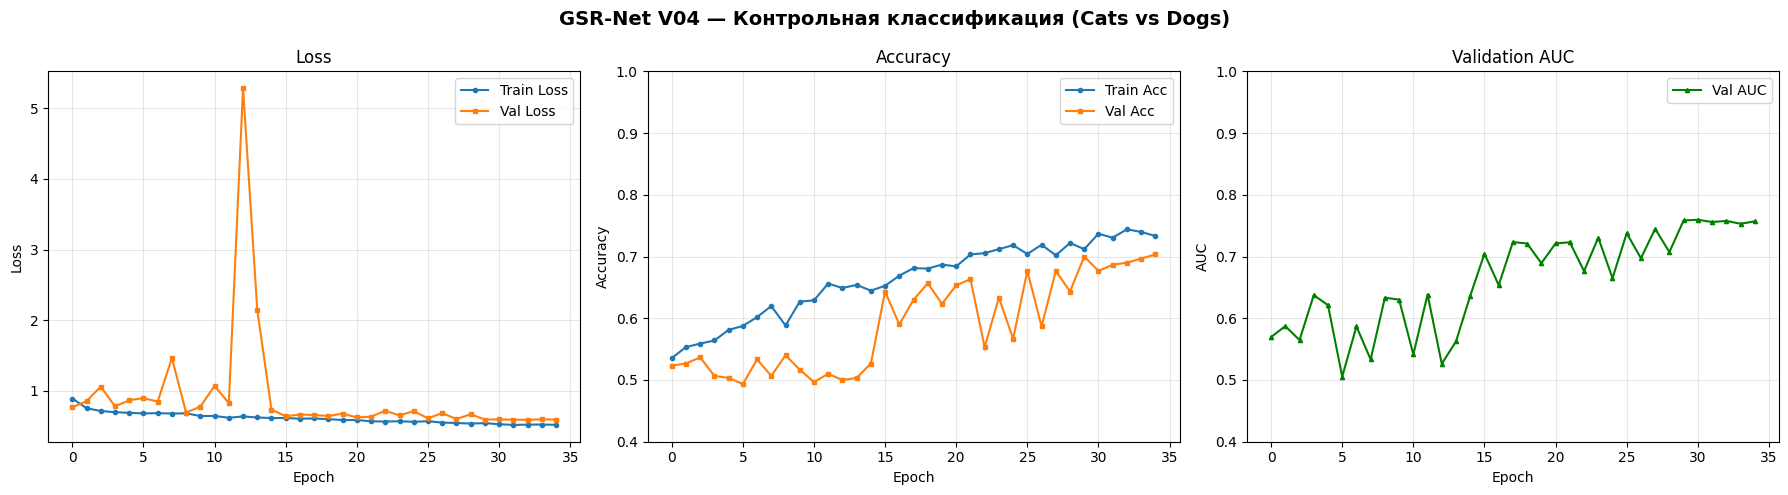

График сохранён: /content/drive/MyDrive/FQW/сat-dog_gsrnet_256_V04/gsrnet_v04_training_history.png


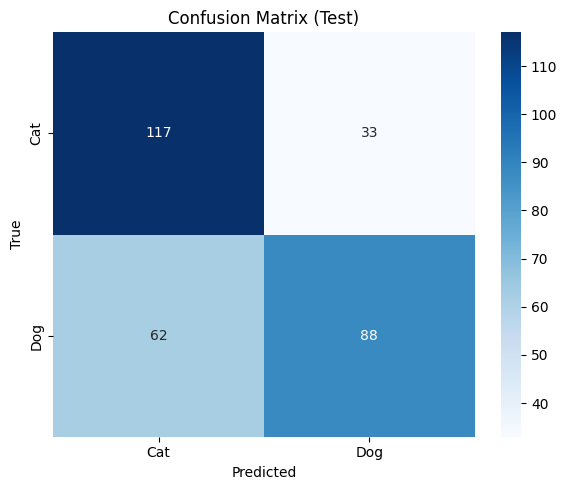

Матрица ошибок: /content/drive/MyDrive/FQW/сat-dog_gsrnet_256_V04/gsrnet_v04_confusion_matrix.png


In [ ]:
# 9. Визуализация результатов

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("GSR-Net V04 — Контрольная классификация (Cats vs Dogs)", fontsize=14, fontweight="bold")

axes[0].plot(history["train_loss"], label="Train Loss", marker="o", markersize=3)
axes[0].plot(history["val_loss"],   label="Val Loss",   marker="s", markersize=3)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train Acc", marker="o", markersize=3)
axes[1].plot(history["val_acc"],   label="Val Acc",   marker="s", markersize=3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.4, 1.0])

axes[2].plot(history["val_auc"], label="Val AUC", marker="^", markersize=3, color="green")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("AUC")
axes[2].set_title("Validation AUC"); axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0.4, 1.0])

plt.tight_layout()
history_path = os.path.join(SAVE_DIR, "gsrnet_v04_training_history.png")
plt.savefig(history_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"График сохранён: {history_path}")

fig2, ax2 = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Cat", "Dog"], yticklabels=["Cat", "Dog"], ax=ax2)
ax2.set_xlabel("Predicted"); ax2.set_ylabel("True")
ax2.set_title("Confusion Matrix (Test)")
plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "gsrnet_v04_confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Матрица ошибок: {cm_path}")

In [ ]:
# 10. Сохранение результатов

results = {
    "experiment": "GSR-Net V04 — контрольная классификация (Cats vs Dogs, grayscale 256)",
    "architecture": "GSR-Net (ResBlock+SE, reduction=4, blocks=[2,2,2,2], ReLU after HPF)",
    "dataset": {
        "name": "Cats-vs-Dogs-Gray-1000",
        "total": len(df),
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
        "split": "holdout 70/15/15",
    },
    "hyperparameters": {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "scheduler": "CosineAnnealingLR(eta_min=1e-5)",
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss",
        "dropout": "Dropout2d(0.1) + Dropout(0.3)",
        "grad_clip": 1.0,
        "augmentations": "HFlip(0.5), VFlip(0.5)",
        "hpf": "learnable (Kaiming init) + ReLU",
        "se_reduction": 4,
        "blocks_per_group": [2, 2, 2, 2],
        "seed": SEED,
    },
    "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
    "best_epoch": best_epoch,
    "results": {
        "test_loss": round(test_loss, 4),
        "test_accuracy": round(test_acc, 4),
        "test_auc": round(test_auc, 4),
        "precision_cat": round(p_cat, 4),
        "recall_cat": round(r_cat, 4),
        "f1_cat": round(f1_cat, 4),
        "precision_dog": round(p_dog, 4),
        "recall_dog": round(r_dog, 4),
        "f1_dog": round(f1_dog, 4),
        "confusion_matrix": cm.tolist(),
    },
    "training_history": history,
    "version_history": {
        "V01": "74.00% / AUC 0.8119 (17.5M, overfitting)",
        "V02": "62.33% / AUC 0.6652 (5.1M, Tanh+Abs → underfitting)",
        "V03": "63.33% / AUC 0.6847 (5.1M, ReLU, too few blocks)",
        "V04": f"{test_acc*100:.2f}% / AUC {test_auc:.4f} (blocks [2,2,2,2], lower Dropout)",
    },
}

json_path = os.path.join(SAVE_DIR, "gsrnet_v04_results.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f"Результаты: {json_path}")

print(f"\n{'='*60}")
print(f"ИТОГО: GSR-Net V04")
print(f"{'='*60}")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test AUC:      {test_auc:.4f}")
print(f"Лучшая эпоха:  {best_epoch}")
print(f"Параметров:    {results['trainable_parameters']:,}")
print(f"Сохранение:    {SAVE_DIR}")
print(f"{'='*60}")

Результаты: /content/drive/MyDrive/FQW/сat-dog_gsrnet_256_V04/gsrnet_v04_results.json

ИТОГО: GSR-Net V04
Test Accuracy: 68.33%
Test AUC:      0.7369
Лучшая эпоха:  31
Параметров:    11,517,890
Сохранение:    /content/drive/MyDrive/FQW/сat-dog_gsrnet_256_V04


## Итог

V04 увеличивает ёмкость модели до 8 блоков [2,2,2,2] (~9.2M параметров) и снижает
регуляризацию (Dropout 0.1/0.3 вместо 0.15/0.4).

